<!-- This notebook is my solution to the thinkonward challenge called speed and structure. I used both Kaggle and Azure ML environments and had to download only the notebook to my local computer. The data for the challenge can be found on the thinkonward github repository. The submission to the platform was done in form of an .npz file containing sample IDs and their corresponding predictions. My best score was 0.0337 MAPE Error level, while the first position on the leaderboard scored 0.232. More details can be found here: https://thinkonward.com/app/c/challenges/speed-and-structure
-->

In [1]:
import torch

try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    # import torch_xla.core.xla_model.xrt_world_size() as xm
    import torch_xla.distributed.parallel_loader as pl
    TPU_AVAILABLE = True
    device = xm.xla_device()
except ImportError:
    TPU_AVAILABLE = False
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Using device: {device}")


[INFO] Using device: cuda


In [2]:
!pip install --quiet huggingface_hub timm scikit-image pyarrow
# !pip install huggingface_hub timm scikit-image pyarrow


In [3]:
!pip install --quiet anytree
!pip install --quiet pytorch-msssim

In [ ]:
# === Standard Libraries ===
import os
import sys
import random
import warnings
from glob import glob
from functools import partial
from typing import Dict, List

# === Scientific and Visualization ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.ndimage as ndi
import scipy.signal as signal
from scipy.ndimage import zoom
from PIL import Image

# === Skimage ===
import skimage.transform as st
from skimage.metrics import structural_similarity as ssim

# === Scikit-learn ===
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# === PyTorch ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# === Transformers ===
from transformers import (
    AutoImageProcessor,
    ViTMAEForPreTraining,
    ViTForMaskedImageModeling,
    ViTImageProcessor,
    ViTImageProcessorFast,
    ViTMAEModel,
)

# === Torchvision ===
from torchvision import transforms
from torchvision.models import resnet18

# === Other Libraries ===
import cv2
import pytorch_msssim
from einops import rearrange
from tqdm import tqdm
from anytree import Node, RenderTree
import pprint as pp

# === Custom Modules ===
# from GFM import ElasticViTMAE

# === Environment Config ===
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.backends.cudnn.benchmark = True

# === Warnings Config ===
warnings.simplefilter(action='ignore', category=FutureWarning)

# === Ensure Directories Exist ===
if not os.path.exists("bonus_training_data"):
    os.makedirs("bonus_training_data")


import torch.nn as nn
from torchvision.models import (
    resnet18, resnet34, resnet50,
    densenet121, mobilenet_v2,
    efficientnet_b0
)



os.environ["HUGGINGFACE_TOKEN"] = "hf_***********"
from huggingface_hub import login
login(token=os.environ["HUGGINGFACE_TOKEN"])


2025-08-06 19:21:27.886645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754508087.909407     138 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754508087.916311     138 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
import os
from glob import glob

# List of directories to pull training samples from
train_dirs = [
    '/kaggle/input/train-200',
    '/kaggle/input/train-300',
    '/kaggle/input/train-500',
    '/kaggle/input/train-1000',  
    '/kaggle/input/train-extra-1',
    '/kaggle/input/train-extra-2',
]

# Collect all individual sample directories
sample_paths = []
for d in train_dirs:
    if os.path.exists(d):
        sample_paths.extend(glob(os.path.join(d, '*')))
    else:
        print(f"[WARN] Directory missing: {d}")

# Extract clean sample IDs (folder names)
sample_paths = sorted(sample_paths)
sample_ids = [os.path.basename(p) for p in sample_paths]

print(f"[✔] Total training samples found: {len(sample_ids)}")


[✔] Total training samples found: 4999


In [6]:
train_dirs

['/kaggle/input/train-200',
 '/kaggle/input/train-300',
 '/kaggle/input/train-500',
 '/kaggle/input/train-1000',
 '/kaggle/input/train-extra-1',
 '/kaggle/input/train-extra-2']

In [7]:
# single source np.ndarray
rec_data = np.load(os.path.join(sample_paths[0], f"receiver_data_src_1.npy"))
print("Receiver data shape:", rec_data.shape)
# target velocity model
target_data = np.load(os.path.join(sample_paths[0], "vp_model.npy"))
print("Target data shape:", target_data.shape)

Receiver data shape: (10001, 31)
Target data shape: (300, 1259)


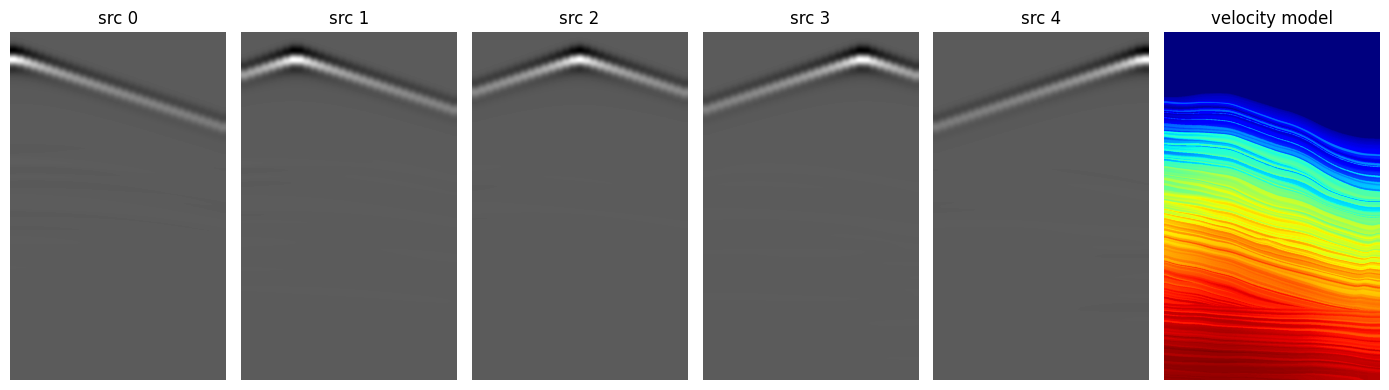

In [8]:
# Plot one dataset sample
sample_path = sample_paths[1]

source_coordinates = [1, 75, 150, 225, 300]

f, ax = plt.subplots(1, 6, figsize=(14, 4))

for i, s in enumerate(source_coordinates):
    rec_data = np.load(os.path.join(sample_path, f"receiver_data_src_{s}.npy"))
    ax[i].imshow(rec_data, cmap="gray", aspect="auto")
    ax[i].set_title(f"src {i}")
    ax[i].axis("off")

target_data = np.load(os.path.join(sample_path, "vp_model.npy"))
ax[-1].imshow(target_data.T, cmap="jet", aspect="auto")
ax[-1].set_title("velocity model")
ax[-1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Calculate score
!pip install anytree
import numpy as np
from anytree import Node, RenderTree
from typing import Dict, List


def dummy_prediction(input_data, output_shape):
    """
    Generates a dummy prediction for velocity model.

    Parameters:
    input_data: list of 5 2D receiver data np.ndarrays

    Returns:
    prediction: A 2D np.ndarray with velocity model prediction
    """

    prediction = np.random.choice(np.linspace(1, 5, 20, dtype=np.float64), size=output_shape)

    return prediction



def create_submission(sample_id: str, prediction, submission_path: str):
    """
    Save prediction into a .npz file under the given sample_id.
    Accepts either a numpy array or a torch tensor (on any device).
    """

    # Ensure prediction is a NumPy array
    if isinstance(prediction, torch.Tensor):
        prediction = prediction.detach().cpu().numpy()

    try:
        submission = dict(np.load(submission_path))
    except Exception:
        submission = {}

    submission[sample_id] = prediction
    np.savez(submission_path, **submission)


def sketch_directory_tree():
    # Create nodes for the directory structure
    root = Node("current_directory")
    starter_notebook = Node("starter_notebook.ipynb", parent=root)
    utils = Node("utils.py", parent=root)
    data = Node("data", parent=root)
    train = Node("train", parent=data)
    test = Node("test", parent=data)

    # Render the directory tree
    for pre, fill, node in RenderTree(root):
        print("%s%s" % (pre, node.name))
    return


def calculate_mape(vel_gt: np.ndarray, vel_pred: np.ndarray) -> float:
    """
    Calculates the Mean Absolute Percentage Error between two 2D NumPy arrays
    of the SAME size.

    The error for each element (i,j) is calculated as:
        abs(vel_gt[i,j] - vel_pred[i,j]) / (vel_gt[i,j] + EPSILON)
    EPSILON is added to the denominator to prevent division by zero.

    Args:
        vel_gt: A 2D NumPy array representing the ground truth values.
        vel_pred: A 2D NumPy array representing the predicted values.
                  Must have the same shape as vel_gt.

    Returns:
        The mean of the normalized absolute errors.
    """
    # Define a small epsilon to prevent division by zero
    EPSILON = 1e-8

    # Calculate the absolute difference element-wise
    absolute_difference = np.abs(vel_gt - vel_pred)

    # Calculate the normalized error element-wise
    # Add EPSILON to vel_gt in the denominator to avoid division by zero
    # and to handle cases where vel_gt[i,j] is 0.
    # If vel_gt[i,j] is 0 and vel_pred[i,j] is also 0, error is 0.
    # If vel_gt[i,j] is 0 and vel_pred[i,j] is non-zero, error is large.
    normalized_error = absolute_difference / (np.abs(vel_gt) + EPSILON)

    # Calculate the mean of the normalized errors
    mape = np.mean(normalized_error)

    return mape

def calculate_score(answerkey_file: str, submission_file: str) -> float:
    """
    Calculates the average mape across multiple samples.

    This function iterates through pairs of groundtruth and predicted velocity models
    stored in npz files. It calculates MAPE for each pair
    using the `calculate_mape` function.

    The final score is the average MAPE over all samples.

    Args:
        answerkey_file: an npz file where keys are string sample identifiers (e.g., IDs)
                   and values are 2D NumPy arrays representing the ground truth
                   velocity models.
        submission_file: an npz file with string keys, ideally matching `answerkey`,
                    where values are 2D NumPy arrays representing the predicted
                    velocity models.

    Returns:
        The average MAPE score across all samples.
    """
    answerkey =  dict(np.load(answerkey_file))
    submission =  dict(np.load(submission_file))

    mape_samples: List[float] = [] # List to store MAPE for samples

    # Iterate through the keys (sample IDs) in the answer key
    for key in answerkey.keys():

        # Retrieve the ground truth and predicted arrays for the current key
        vel_gt = answerkey[key]
        vel_pred = submission[key]

        # Calculate the MAPE for the current sample using the helper function
        mape_score = calculate_mape(vel_gt, vel_pred)
        mape_samples.append(mape_score)

    return float(np.mean(mape_samples))

In [ ]:
import numpy as np
import random
import scipy.ndimage as ndi
import scipy.signal as signal
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.ndimage import zoom
from glob import glob
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import os

# === DATASET + AUGMENTATION ===
class SeismicDataset(Dataset):
    def __init__(self, sample_paths, augment=False):
        # self.root_dir = root_dir
        self.sample_paths = sample_paths
        self.augment = augment
        self.source_coords = [1, 75, 150, 225, 300]

    def __len__(self):
        return len(self.sample_paths)

    def __getitem__(self, idx):
        sample_path = self.sample_paths[idx]
        sample_id = os.path.basename(sample_path)

        receivers = []
        for s in self.source_coords:
            r = np.load(os.path.join(sample_path, f"receiver_data_src_{s}.npy")).astype(np.float32)
            r /= np.max(np.abs(r))  # Normalize

            if self.augment:
                r = apply_augmentations(r, CONFIG['augmentations'])
            receivers.append(r)

        receiver_stack = torch.from_numpy(np.stack(receivers)).float()
        receiver_stack = F.interpolate(receiver_stack.unsqueeze(0), size=(256, 256), mode='bilinear').squeeze(0)

        vp = np.load(os.path.join(sample_path, "vp_model.npy")).astype(np.float32)
        vp = torch.from_numpy(vp).unsqueeze(0).float()
        vp = F.interpolate(vp.unsqueeze(0), size=(256, 256), mode='bilinear').squeeze(0)

        if CONFIG['normalize_target']:  # 🔧 normalize target if enabled
              # === Normalize target ===
            vp = (vp - vp.min()) / (vp.max() - vp.min() + 1e-8)

        return receiver_stack, vp

def generate_csp(self, r):
        """
        Randomly shuffle 20% of the trace columns to simulate CSP corruption.
        """
        W = r.shape[1]
        num_swap = int(W * 0.2)
        indices = np.random.choice(W, num_swap, replace=False)
        swap_with = np.random.permutation(indices)
        r[:, indices] = r[:, swap_with]
        return r

        # === CONV BLOCKS SHARED ===    

class DoubleConv(nn.Module):
    """Two consecutive Conv2D + BatchNorm + ReLU operations"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),  # preserve spatial size
            nn.BatchNorm2d(out_channels),  # normalize activations for stable training
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downsampling with MaxPool followed by DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),               # reduce H, W by 2; assumes spatial correlation
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.pool_conv(x)

class Up(nn.Module):
    """Upsampling then DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels)  # in_channels = concat(C1, C2)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle size mismatch (e.g. from padding) during upsampling
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)  # concatenate encoder & decoder features
        return self.conv(x)

class UNet1(nn.Module):
    """
    Basic UNet architecture for velocity prediction.
    Strengths:
        - Good for dense prediction tasks.
        - Uses skip connections for localization.
    Weaknesses:
        - May oversmooth outputs, losing fine structures like faults.
        - Decoder lacks attention or residual mechanisms.
    """
    def __init__(self, n_channels, n_outputs):
        super(UNet1, self).__init__()
        
        # Encoder path (contracting path)
        self.inc = DoubleConv(n_channels, 64)       # First block
        self.down1 = Down(64, 128)                  # Downsample 1
        self.down2 = Down(128, 256)                 # Downsample 2
        self.down3 = Down(256, 512)                 # Downsample 3
        self.down4 = Down(512, 512)                 # Bottleneck

        # Decoder path (expansive path)
        self.up1 = Up(1024, 256)                    # Up from 512 + 512
        self.up2 = Up(512, 128)                     # Up from 256 + 256
        self.up3 = Up(256, 64)                      # Up from 128 + 128
        self.up4 = Up(128, 64)                      # Up from 64 + 64

        # Final 1x1 conv maps to velocity values
        self.outc = nn.Conv2d(64, n_outputs, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)       # 64
        x2 = self.down1(x1)    # 128
        x3 = self.down2(x2)    # 256
        x4 = self.down3(x3)    # 512
        x5 = self.down4(x4)    # 512

        # Decoder with skip connections
        x = self.up1(x5, x4)   # Combine 512 + 512 → 256
        x = self.up2(x, x3)    # 256 + 256 → 128
        x = self.up3(x, x2)    # 128 + 128 → 64
        x = self.up4(x, x1)    # 64 + 64 → 64

        return self.outc(x)


# --- Residual Block ---
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.conv(x))

# --- Attention Gate ---
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        # Upsample g1 to match x1
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AGResUNet(nn.Module):
    """
    Residual + Attention UNet for seismic velocity.
    Strengths:
        - Residual blocks preserve information and allow deeper learning.
        - Attention Gates help the decoder focus on useful features (e.g., faults, salt boundaries).
        - Helps recover sharper boundaries and small-scale details.
    Weakness:
        - Slightly heavier compute cost than vanilla UNet.
    """
    def __init__(self, n_channels, n_outputs):
        super().__init__()
        
        # Initial convolution + residual block
        self.inc = DoubleConv(n_channels, 64)
        self.res1 = ResidualBlock(64)

        # Downsampling path
        self.down1 = Down(64, 128)
        self.res2 = ResidualBlock(128)

        self.down2 = Down(128, 256)
        self.res3 = ResidualBlock(256)

        self.down3 = Down(256, 512)
        self.res4 = ResidualBlock(512)

        self.down4 = Down(512, 512)  # bottleneck

        # Decoder with Attention-Gated skip connections
        self.up1 = Up(1024, 256)
        self.ag1 = AttentionGate(F_g=512, F_l=512, F_int=256)

        self.up2 = Up(512, 128)
        self.ag2 = AttentionGate(F_g=256, F_l=256, F_int=128)

        self.up3 = Up(256, 64)
        self.ag3 = AttentionGate(F_g=128, F_l=128, F_int=64)

        self.up4 = Up(128, 64)
        self.ag4 = AttentionGate(F_g=64, F_l=64, F_int=32)

        # Final prediction layer
        self.outc = nn.Conv2d(64, n_outputs, kernel_size=1)

    def forward(self, x):
        # Encoder + residual enrichment
        x1 = self.res1(self.inc(x))     # 64
        x2 = self.res2(self.down1(x1))  # 128
        x3 = self.res3(self.down2(x2))  # 256
        x4 = self.res4(self.down3(x3))  # 512
        x5 = self.down4(x4)             # 512 bottleneck

        # Decoder with attention at each skip connection
        g1 = self.ag1(x5, x4)
        x = self.up1(x5, g1)

        g2 = self.ag2(x, x3)
        x = self.up2(x, g2)

        g3 = self.ag3(x, x2)
        x = self.up3(x, g3)

        g4 = self.ag4(x, x1)
        x = self.up4(x, g4)

        return self.outc(x)

class AGResUNetMultiTask(nn.Module):
    def __init__(self, n_channels, n_regression_outputs=1, n_segmentation_classes=1):
        super().__init__()
        
        # === Shared encoder + residual enrichment ===
        self.inc = DoubleConv(n_channels, 64)
        self.res1 = ResidualBlock(64)
        self.down1 = Down(64, 128)
        self.res2 = ResidualBlock(128)
        self.down2 = Down(128, 256)
        self.res3 = ResidualBlock(256)
        self.down3 = Down(256, 512)
        self.res4 = ResidualBlock(512)
        self.down4 = Down(512, 512)

        # === Decoder for velocity regression ===
        self.ag1_v = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.up1_v = Up(1024, 256)
        self.ag2_v = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.up2_v = Up(512, 128)
        self.ag3_v = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.up3_v = Up(256, 64)
        self.ag4_v = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.up4_v = Up(128, 64)
        self.outc_v = nn.Conv2d(64, n_regression_outputs, kernel_size=1)

        # === Decoder for segmentation (salt/fault) ===
        self.ag1_s = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.up1_s = Up(1024, 256)
        self.ag2_s = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.up2_s = Up(512, 128)
        self.ag3_s = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.up3_s = Up(256, 64)
        self.ag4_s = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.up4_s = Up(128, 64)
        self.outc_s = nn.Conv2d(64, n_segmentation_classes, kernel_size=1)

    def forward(self, x):
        # === Shared Encoder ===
        x1 = self.res1(self.inc(x))     # 64
        x2 = self.res2(self.down1(x1))  # 128
        x3 = self.res3(self.down2(x2))  # 256
        x4 = self.res4(self.down3(x3))  # 512
        x5 = self.down4(x4)             # 512 bottleneck

        # === Velocity Decoder ===
        g1_v = self.ag1_v(x5, x4)
        xv = self.up1_v(x5, g1_v)
        g2_v = self.ag2_v(xv, x3)
        xv = self.up2_v(xv, g2_v)
        g3_v = self.ag3_v(xv, x2)
        xv = self.up3_v(xv, g3_v)
        g4_v = self.ag4_v(xv, x1)
        xv = self.up4_v(xv, g4_v)
        velocity_pred = self.outc_v(xv)

        # === Segmentation Decoder ===
        g1_s = self.ag1_s(x5, x4)
        xs = self.up1_s(x5, g1_s)
        g2_s = self.ag2_s(xs, x3)
        xs = self.up2_s(xs, g2_s)
        g3_s = self.ag3_s(xs, x2)
        xs = self.up3_s(xs, g3_s)
        g4_s = self.ag4_s(xs, x1)
        xs = self.up4_s(xs, g4_s)
        seg_pred = self.outc_s(xs)

        return velocity_pred, seg_pred

class DiffusionGDM(nn.Module):
    def __init__(self, in_c=5, out_c=1):
        super().__init__()
        self.unet = UNet1(in_c + 1, out_c)

    def forward(self, x, t):
        noise_level = t.view(-1, 1, 1, 1).expand(x.size(0), 1, x.size(2), x.size(3))
        xt = torch.cat([x, noise_level], dim=1)  # xt: [B, 6, H, W]
        return self.unet(xt)

    def __init__(self, n_channels, n_outputs):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.res1 = ResidualBlock(64)
        self.down1 = Down(64, 128)
        self.res2 = ResidualBlock(128)
        self.down2 = Down(128, 256)
        self.res3 = ResidualBlock(256)
        self.down3 = Down(256, 512)
        self.res4 = ResidualBlock(512)
        self.down4 = Down(512, 512)

        self.up1 = Up(1024, 256)
        self.ag1 = AttentionGate(512, 512, 256)
        self.up2 = Up(512, 128)
        self.ag2 = AttentionGate(256, 256, 128)
        self.up3 = Up(256, 64)
        self.ag3 = AttentionGate(128, 128, 64)
        self.up4 = Up(128, 64)
        self.ag4 = AttentionGate(64, 64, 32)

        self.outc = nn.Conv2d(64, n_outputs, kernel_size=1)

    def forward(self, x):
        x1 = self.res1(self.inc(x))     # 64
        x2 = self.res2(self.down1(x1))  # 128
        x3 = self.res3(self.down2(x2))  # 256
        x4 = self.res4(self.down3(x3))  # 512
        x5 = self.down4(x4)             # 512

        g1 = self.ag1(x5, x4)
        x = self.up1(x5, g1)
        g2 = self.ag2(x, x3)
        x = self.up2(x, g2)
        g3 = self.ag3(x, x2)
        x = self.up3(x, g3)
        g4 = self.ag4(x, x1)
        x = self.up4(x, g4)

        return self.outc(x)


# === Set global seeds ===
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = CONFIG['seed'] + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# def mape_loss(pred, target, epsilon=1e-5):
#     return (torch.abs((target - pred) / (target + epsilon))).mean()


from pytorch_msssim import ssim as ssim_fn


def mse_loss(pred, target):
    return F.mse_loss(pred, target)

def mae_loss(pred, target):
    return F.l1_loss(pred, target)

def smooth_l1_loss(pred, target, beta=1.0):
    return F.smooth_l1_loss(pred, target, beta=beta)

def huber_loss(pred, target, delta=1.0):
    return F.huber_loss(pred, target, delta=delta)

def mape_loss(pred, target, eps=1e-6):
    return torch.mean(torch.abs((target - pred) / (target + eps))) * 100

# === MULTISCALE LOSS ===
def multiscale_mse_loss(pred, target):
    """
    Computes MSE at original scale + downsampled versions.
    """
    loss = F.mse_loss(pred, target)
    for scale in [0.5, 0.25]:
        pred_ds = F.interpolate(pred, scale_factor=scale, mode='bilinear', align_corners=False)
        target_ds = F.interpolate(target, scale_factor=scale, mode='bilinear', align_corners=False)
        loss += F.mse_loss(pred_ds, target_ds)
    return loss

# === MAE + GRADIENT LOSS ===
def mae_gradient_loss(pred, target, alpha=0.5):
    mae = F.l1_loss(pred, target)
    grad_pred_x = torch.diff(pred, dim=2)
    grad_pred_y = torch.diff(pred, dim=3)
    grad_target_x = torch.diff(target, dim=2)
    grad_target_y = torch.diff(target, dim=3)
    grad_loss = (F.l1_loss(grad_pred_x, grad_target_x) + F.l1_loss(grad_pred_y, grad_target_y)) / 2
    return alpha * mae + (1 - alpha) * grad_loss

# === COMPOUND LOSSES ===
def hybrid_mse_ssim_loss(pred, target, alpha=0.1):
    """
    Combines MSE with SSIM loss.
    """
    return F.mse_loss(pred, target) + alpha * SSIMLoss()(pred, target)

def combined_mse_ssim_loss(pred, target, alpha=0.5):
    mse = F.mse_loss(pred, target)
    ssim_val = 1.0 - ssim(pred, target, data_range=1.0, size_average=True)
    return mse + alpha * ssim_val

def mape_ssim_loss(pred, target, beta=0.5):
    return beta * mape_loss(pred, target) + (1 - beta) * SSIMLoss()(pred, target)

# === DICE LOSS (useful for segmentation-like boundary preservation) ===
def dice_loss(pred, target, smooth=1e-6):
    pred_flat = pred.view(pred.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    intersection = (pred_flat * target_flat).sum(1)
    return 1 - ((2. * intersection + smooth) / (pred_flat.sum(1) + target_flat.sum(1) + smooth)).mean()

# === SSIM Loss ===
class SSIMLoss(nn.Module):
    def __init__(self, data_range=1.0):
        super().__init__()
        self.data_range = data_range

    # def forward(self, pred, target):
    #     return 1 - pytorch_msssim.ssim(pred, target, data_range=self.data_range, size_average=True)
    def forward(self, pred, target):
        pred = pred.float()
        target = target.float()
        return 1 - pytorch_msssim.ssim(pred, target, data_range=self.data_range, size_average=True)


# === Squared Dice Loss ===
class SquaredDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.contiguous()
        target = target.contiguous()
        intersection = (pred * target).sum(dim=(1, 2, 3))
        union = pred.square().sum(dim=(1, 2, 3)) + target.square().sum(dim=(1, 2, 3))
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean()

# === Binary Focal Loss ===
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        bce_loss = self.bce(pred, target)
        prob = torch.sigmoid(pred)
        pt = torch.where(target == 1, prob, 1 - prob)
        focal_term = self.alpha * (1 - pt) ** self.gamma
        return (focal_term * bce_loss).mean()

# === MAPE + L2 ===
def mape_loss(pred, target, epsilon=1e-5):
    return (torch.abs((target - pred) / (target + epsilon))).mean()

def mape_l2_loss(pred, target):
    return mape_loss(pred, target) + 0.01 * F.mse_loss(pred, target)

def mape_ssim_loss(pred, target):
    mape = mape_loss(pred, target)
    with torch.cuda.amp.autocast(enabled=False):
        ssim_val = 1 - pytorch_msssim.ssim(pred.float(), target.float(), data_range=1.0, size_average=True)
    return mape + ssim_val


# === Masked MSE Loss ===
def masked_mse(pred, target, mask):
    diff = (pred - target) * mask
    return torch.sum(diff ** 2) / (torch.sum(mask) + 1e-8)

# === Fourier Loss (useful for structural alignment) ===
def fourier_loss(pred, target):
    pred_fft = torch.fft.fftshift(torch.fft.fft2(pred))
    target_fft = torch.fft.fftshift(torch.fft.fft2(target))
    return F.mse_loss(torch.abs(pred_fft), torch.abs(target_fft))

# === Multi-Scale Loss ===
def multiscale_loss(pred, target):
    loss = F.mse_loss(pred, target)
    for scale in [0.5, 0.25]:
        pred_ds = F.interpolate(pred, scale_factor=scale, mode='bilinear', align_corners=False)
        target_ds = F.interpolate(target, scale_factor=scale, mode='bilinear', align_corners=False)
        loss += F.mse_loss(pred_ds, target_ds)
    return loss

# === Hybrid Loss (MSE + SSIM) ===
def hybrid_loss(pred, target):
    return F.mse_loss(pred, target) + 0.1 * SSIMLoss()(pred, target)

# === Generate Path Mask for Fault/Salt-aware Regions ===
def generate_random_path_mask(shape, num_points=3): #fewer points → shorter, sharper attention lines
    H, W = shape
    points = np.stack([np.random.randint(0, W, num_points),
                       np.random.randint(0, H, num_points)], axis=1)
    mask = np.zeros((H, W), dtype=np.uint8)
    for i in range(len(points)-1):
        cv2.line(mask, tuple(points[i]), tuple(points[i+1]), 1, 1)
    return mask.astype(np.float32)
    
class LossScheduler(nn.Module):
    def __init__(self, base_losses: List[nn.Module], weights: List[float], strategy="linear_decay"):
        super().__init__()
        self.base_losses = base_losses
        self.weights = weights
        self.strategy = strategy
        self.register_buffer('current_epoch', torch.tensor(0.))

    def set_epoch(self, epoch):
        self.current_epoch = torch.tensor(epoch, dtype=torch.float32)

    def forward(self, pred, target):
        total_loss = 0.0
        for i, loss_fn in enumerate(self.base_losses):
            weight = self._compute_weight(i)
            total_loss += weight * loss_fn(pred, target)
        return total_loss

    def _compute_weight(self, i):
        if self.strategy == "linear_decay":
            decay_factor = max(0.0, 1.0 - self.current_epoch / 50.0)  # 50 epochs decay
            return self.weights[i] * decay_factor
        elif self.strategy == "fixed":
            return self.weights[i]
        else:
            raise ValueError(f"Unknown strategy {self.strategy}")

class CompositeLossScheduler(nn.Module):
    def __init__(self, loss_funcs, start_weights, end_weights, total_epochs):
        super().__init__()
        self.loss_funcs = loss_funcs
        self.start_weights = torch.tensor(start_weights)
        self.end_weights = torch.tensor(end_weights)
        self.total_epochs = total_epochs
        self.current_epoch = 0

    def set_epoch(self, epoch):
        self.current_epoch = epoch

    def forward(self, pred, target):
        alpha = self.current_epoch / self.total_epochs
        weights = (1 - alpha) * self.start_weights + alpha * self.end_weights
        total_loss = 0.0
        for w, f in zip(weights, self.loss_funcs):
            total_loss += w * f(pred, target)
        return total_loss

class PathAwareLoss(nn.Module):
    def __init__(self, base_loss_fn=F.mse_loss, num_paths=3, weight=0.3):
        super().__init__()
        self.base_loss_fn = base_loss_fn
        self.num_paths = num_paths
        self.weight = weight  # how much to weigh path-aware loss

    def forward(self, pred, target):
        assert pred.shape == target.shape, "Shape mismatch"
        total_loss = self.base_loss_fn(pred, target)

        B, C, H, W = pred.shape
        mask_tensor = torch.zeros_like(pred)

        for b in range(B):
            for _ in range(self.num_paths):
                path_mask_np = generate_random_path_mask((H, W))
                path_mask_tensor = torch.tensor(path_mask_np, dtype=torch.float32, device=pred.device)
                mask_tensor[b] += path_mask_tensor

        mask_tensor = (mask_tensor > 0).float()
        path_loss = masked_mse(pred, target, mask_tensor)

        return total_loss + self.weight * path_loss

def hybrid_geological_loss(pred, target):
    mse = F.mse_loss(pred, target)
    ssim_l = SSIMLoss()(pred, target)
    fourier = fourier_loss(pred, target)
    return mse + 0.3 * ssim_l + 0.1 * fourier

def weighted_hybrid_with_path_mask(pred, target):
    mask = generate_random_path_mask(pred.shape[-2:])  # H, W
    mask = torch.tensor(mask, device=pred.device).unsqueeze(0).unsqueeze(0)  # shape: [1,1,H,W]
    masked = masked_mse(pred, target, mask)
    return 0.7 * F.mse_loss(pred, target) + 0.4 * masked

def weighted_hybrid_salt_path_mask(pred, target, salt_threshold=3.0):
    salt = salt_region_loss(pred, target, threshold=salt_threshold)
    mask = generate_random_path_mask(pred.shape[-2:])  # H, W
    mask = torch.tensor(mask, device=pred.device).unsqueeze(0).unsqueeze(0)  # shape: [1,1,H,W]
    masked = masked_mse(pred, target, mask)
    return 0.7 * F.mse_loss(pred, target) + 0.3 * masked + salt #weighted_hybrid_salt_path_mask

def weighted_hybrid_with_path_mask2(pred, target):
    mask = generate_random_path_mask(pred.shape[-2:])  # H, W
    mask = torch.tensor(mask, device=pred.device).unsqueeze(0).unsqueeze(0)

    masked = masked_mse(pred, target, mask)

    # Gradient difference penalty
    grad_pred_x = torch.diff(pred, dim=2)
    grad_pred_y = torch.diff(pred, dim=3)
    grad_target_x = torch.diff(target, dim=2)
    grad_target_y = torch.diff(target, dim=3)
    grad_loss = (F.l1_loss(grad_pred_x, grad_target_x) + F.l1_loss(grad_pred_y, grad_target_y)) / 2

    return 0.6 * F.mse_loss(pred, target) + 0.4 * masked + 0.1 * grad_loss

def salt_region_loss(pred, target, threshold=4.0):
    """
    Penalizes errors in regions where the target velocity exceeds a salt threshold.
    """
    mask = (target > threshold).float()
    return F.l1_loss(pred * mask, target * mask)
    
def mape_ssim_salt_loss(pred, target, salt_weight=0.5, salt_threshold=4.0):
    mape = mape_loss(pred, target)
    ssim_val = 1 - pytorch_msssim.ssim(pred, target, data_range=1.0, size_average=True)
    salt = salt_region_loss(pred, target, threshold=salt_threshold)
    return mape + ssim_val + salt_weight * salt

def mape_salt_loss(pred, target, salt_weight=0.5, salt_threshold=4.0):
    mape = mape_loss(pred, target)
    # ssim_val = 1 - pytorch_msssim.ssim(pred, target, data_range=1.0, size_average=True)
    salt = salt_region_loss(pred, target, threshold=salt_threshold)
    return mape + salt_weight * salt

def get_salt_mask(velocity, velocity_thresh=4.0):
    """
    Converts a velocity map to a binary salt mask.
    Salt is defined where velocity exceeds the threshold.
    """
    return (velocity > velocity_thresh).float()

def dice_loss(pred_mask, true_mask, smooth=1e-6):
    """
    Computes Dice loss between two binary masks.
    """
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum()
    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice

def composite_salt_loss(pred, target, alpha=0.5, velocity_thresh=4.0):
    """
    Combines SmoothL1Loss with Dice loss on salt masks.

    Args:
        pred: [B, 1, H, W] predicted velocity
        target: [B, 1, H, W] ground truth velocity
        alpha: weight for salt dice loss
        velocity_thresh: threshold for defining salt bodies
    """
    # Regression loss (Smooth L1)
    l1 = F.smooth_l1_loss(pred, target)

    # Salt region masks
    pred_mask = get_salt_mask(pred, velocity_thresh)
    true_mask = get_salt_mask(target, velocity_thresh)

    # Dice loss on binary masks
    salt_dice = dice_loss(pred_mask, true_mask)

    total_loss = l1 + alpha * salt_dice
    return total_loss

def hybrid_dice_focal_loss(pred, target):
    dice = SquaredDiceLoss()(pred, target)
    focal = BinaryFocalLoss()(pred, target)
    return 0.5 * dice + 0.5 * focal


class LightPathAwareSharpenLoss(nn.Module):
    def __init__(self, total_epochs, alpha_start=0.1, alpha_end=0.3, grad_weight=0.1, num_paths=1):
        super().__init__()
        self.total_epochs = total_epochs
        self.alpha_start = alpha_start
        self.alpha_end = alpha_end
        self.grad_weight = grad_weight
        self.num_paths = num_paths
        self.current_epoch = 0
        self.ssim_loss = SSIMLoss()

    def set_epoch(self, epoch):
        self.current_epoch = epoch

    def forward(self, pred, target):
        alpha = self.alpha_start + (self.alpha_end - self.alpha_start) * (self.current_epoch / self.total_epochs)

        mse = F.mse_loss(pred, target)

        # Light Path Mask (small strokes)
        path_mask = self.generate_small_path_mask(pred.shape[-2:], stroke_length=20)
        path_mask_tensor = torch.tensor(path_mask, device=pred.device).unsqueeze(0).unsqueeze(0)
        path_loss = masked_mse(pred, target, path_mask_tensor)

        # Gradient preservation loss
        grad_loss = self.gradient_loss(pred, target)

        total_loss = (1 - alpha) * mse + alpha * path_loss + self.grad_weight * grad_loss
        return total_loss

    def generate_small_path_mask(self, shape, stroke_length=20):
        H, W = shape
        start_point = (np.random.randint(0, W), np.random.randint(0, H))
        angle = np.random.uniform(0, 2 * np.pi)
        end_point = (int(start_point[0] + stroke_length * np.cos(angle)),
                     int(start_point[1] + stroke_length * np.sin(angle)))
        end_point = (np.clip(end_point[0], 0, W - 1), np.clip(end_point[1], 0, H - 1))

        mask = np.zeros((H, W), dtype=np.uint8)
        cv2.line(mask, start_point, end_point, 1, 1)
        return mask.astype(np.float32)

    def gradient_loss(self, pred, target):
        grad_pred_x = torch.diff(pred, dim=2)
        grad_pred_y = torch.diff(pred, dim=3)
        grad_target_x = torch.diff(target, dim=2)
        grad_target_y = torch.diff(target, dim=3)

        grad_loss = (F.l1_loss(grad_pred_x, grad_target_x) + F.l1_loss(grad_pred_y, grad_target_y)) / 2
        return grad_loss


class ProgressivePathAwareLoss(nn.Module):
    def __init__(self, total_epochs, alpha_start=0.3, alpha_end=0.7, ssim_weight=0.1, num_paths=3):
        super().__init__()
        self.total_epochs = total_epochs
        self.alpha_start = alpha_start
        self.alpha_end = alpha_end
        self.ssim_weight = ssim_weight
        self.num_paths = num_paths
        self.current_epoch = 0
        self.ssim_loss = SSIMLoss()

    def set_epoch(self, epoch):
        self.current_epoch = epoch

    def forward(self, pred, target):
        # Calculate progressive alpha (path weight)
        alpha = self.alpha_start + (self.alpha_end - self.alpha_start) * (self.current_epoch / self.total_epochs)

        mse = F.mse_loss(pred, target)
        path_mask = self.generate_progressive_path_mask(pred.shape[-2:], epoch=self.current_epoch)
        path_mask_tensor = torch.tensor(path_mask, device=pred.device).unsqueeze(0).unsqueeze(0)

        path_loss = masked_mse(pred, target, path_mask_tensor)
        ssim_l = self.ssim_loss(pred, target)

        total_loss = (1 - alpha) * mse + alpha * path_loss + self.ssim_weight * ssim_l
        return total_loss

    def generate_progressive_path_mask(self, shape, epoch):
        """
        Increase path complexity over time.
        """
        num_points = min(3 + epoch // 10, 15)  # Progressively increase points
        H, W = shape
        points = np.stack([np.random.randint(0, W, num_points),
                           np.random.randint(0, H, num_points)], axis=1)
        mask = np.zeros((H, W), dtype=np.uint8)
        for i in range(len(points) - 1):
            cv2.line(mask, tuple(points[i]), tuple(points[i + 1]), 1, 1)
        return mask.astype(np.float32)


def get_loss_function(arch_name, total_epochs=None):
    
    if arch_name == 'mse':
        return F.mse_loss
    elif arch_name == 'mae':
        return F.l1_loss
    elif arch_name == 'smoothl1':
        return nn.SmoothL1Loss()
    elif arch_name == "mape":
        return mape_loss
    elif arch_name == "mape_l2":
        return mape_l2_loss
    elif arch_name == 'huber':
        return nn.HuberLoss()
    elif arch_name == 'mae_grad':
        return mae_gradient_loss
    elif arch_name == 'mape_ssim':
        return mape_ssim_loss
    elif arch_name == 'mape_salt':
        return mape_salt_loss
    elif arch_name == 'composite_salt':
        return composite_salt_loss
    elif arch_name == "ssim":
        return SSIMLoss()
    elif arch_name == "hybrid_geo":
        return hybrid_geological_loss
    elif arch_name == "hybrid_masked2":
        return weighted_hybrid_with_path_mask2
    elif arch_name == "hybrid_masked":
        return weighted_hybrid_with_path_mask
    elif arch_name == "hybrid_salt_masked":
        return weighted_hybrid_salt_path_mask
    elif arch_name == "hybrid_dice_focal":
        return hybrid_dice_focal_loss
    elif arch_name == "path_aware":
        return PathAwareLoss(base_loss_fn=F.mse_loss, num_paths=5, weight=0.5)
    elif arch_name == 'pro-path-aware':
        if total_epochs is None:
            raise ValueError("total_epochs must be specified for progressive path-aware loss.")
        return ProgressivePathAwareLoss(total_epochs=total_epochs)
    elif arch_name == 'light-path-aware':
        if total_epochs is None:
            raise ValueError("total_epochs must be specified for progressive path-aware loss.")
        return LightPathAwareLoss(total_epochs=total_epochs)
    elif arch_name == "scheduler":
        return LossScheduler(
            base_losses=[F.mse_loss, SSIMLoss(), fourier_loss],
            weights=[1.0, 0.5, 0.2],
            strategy="linear_decay"
        )
    elif arch_name == "compo_scheduler":
        return CompositeLossScheduler(
            loss_funcs=[nn.MSELoss(), SSIMLoss(), fourier_loss],
            start_weights=[1.0, 0.0, 0.0],
            end_weights=[0.3, 0.3, 0.4],
            total_epochs=5
       )            
    else:
        raise ValueError(f"Loss {arch_name} not supported.")


# === WELL LOG INTEGRATION ===

def extract_well_logs(volume, num_wells=3, seed=77):
    """
    Extract random well logs (vertical columns) from the seismic volume.
    Returns: list of (b, x) positions
    """
    if isinstance(volume, torch.Tensor):
        vol = volume.detach().cpu().numpy()
    else:
        vol = volume

    if vol.ndim == 4 and vol.shape[1] == 1:
        vol = vol.squeeze(1)

    positions = []

    if vol.ndim == 3:  # (B, H, W)
        B, H, W = vol.shape
        np.random.seed(seed)
        for b in range(B):
            for _ in range(num_wells):
                x = np.random.randint(0, W)
                positions.append((b, x))
        return positions
    elif vol.ndim == 2:  # (H, W)
        H, W = vol.shape
        np.random.seed(seed)
        for _ in range(num_wells):
            x = np.random.randint(0, W)
            positions.append((0, x))  # assume single sample
        return positions
    else:
        raise ValueError("Input volume must have shape (B, H, W) or (H, W)")



def well_log_loss(pred, target, log_positions, criterion=torch.nn.MSELoss()):
    """
    Computes vertical column-wise loss between prediction and target at specified (b, x) positions.
    """
    loss = 0.0
    for (b, x) in log_positions:
        pred_log = pred[b, :, x]  # shape: (H,)
        target_log = target[b, :, x]
        loss += criterion(pred_log, target_log)

    return loss / len(log_positions)


def log_well_loss_per_epoch(pred, target, num_wells=3):
    """
    Return well-log loss value from prediction and target volumes for logging.
    """
    logs = extract_well_logs(target, num_wells=num_wells)
    return well_log_loss(pred, target, logs).item()

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def denormalize(vp_norm):
    return vp_norm * (x.max() - x.min() +  x.min())


def apply_augmentations(r: np.ndarray, aug_config: dict) -> np.ndarray:
    """
    Applies reproducible augmentations to a receiver gather.

    Args:
        r: (H, W) input array
        aug_config: dictionary of augmentation options

    Returns:
        Augmented receiver gather
    """
    if aug_config.get('hflip', False):
        if random.random() < 0.5:
            r = np.flip(r, axis=1).copy()
            
    if aug_config.get('vflip', False):
        if random.random() < 0.5:
            r = np.flip(r, axis=2).copy()

    if aug_config.get('add_noise', False):
        std = 0.05 * np.std(r)
        noise = np.random.normal(0, std, r.shape).astype(np.float32)
        r += noise

    if aug_config.get('scale', False):
        factor = np.random.uniform(0.8, 1.2)
        r *= factor

    if aug_config.get('depth_shift', False):
        max_shift = aug_config.get('depth_shift_max', 20)
        shift = random.randint(-max_shift, max_shift)
        r = np.roll(r, shift, axis=0)

    if aug_config.get('random_distortion', False):
        distortion_strength = aug_config.get('distortion_strength', 0.3)
        noise = np.random.randn(*r.shape) * distortion_strength
        r += ndi.gaussian_filter(noise, sigma=1)

    if aug_config.get('elastic_deform', False):
        alpha = aug_config.get('elastic_alpha', 20)
        sigma = aug_config.get('elastic_sigma', 4)
        dx = ndi.gaussian_filter((np.random.rand(*r.shape) * 2 - 1), sigma, mode='constant') * alpha
        dy = ndi.gaussian_filter((np.random.rand(*r.shape) * 2 - 1), sigma, mode='constant') * alpha
        coords = np.meshgrid(np.arange(r.shape[0]), np.arange(r.shape[1]), indexing='ij')
        indices = np.reshape(coords[0] + dx, (-1, 1)), np.reshape(coords[1] + dy, (-1, 1))
        r = ndi.map_coordinates(r, indices, order=1, mode='reflect').reshape(r.shape)

    if aug_config.get('bandpass_filter', False):
        low = aug_config.get('bandpass_low', 5)
        high = aug_config.get('bandpass_high', 45)
        fs = aug_config.get('bandpass_fs', 100)
        b, a = signal.butter(2, [low / (0.5 * fs), high / (0.5 * fs)], btype='band')
        for i in range(r.shape[1]):
            r[:, i] = signal.filtfilt(b, a, r[:, i], padlen=50)

    if aug_config.get('csp', False):
        # Randomly zero out or shuffle some channels (trace columns)
        W = r.shape[1]
        num_swap = int(W * 0.2)
        indices = np.random.choice(W, num_swap, replace=False)
        swap_with = np.random.permutation(indices)
        r[:, indices] = r[:, swap_with]

    return r.astype(np.float32)

def get_model(arch_name):
    in_c = CONFIG['input_channels']
    out_c = CONFIG['output_channels']

    if arch_name.lower() == 'unet1':
        return UNet1(in_c, out_c)
    # elif arch_name.lower() == 'unet2':
    #     return UNet2(input_channels=in_c, output_channels=out_c)
    # elif arch_name.lower() == 'ounet':
    #     return OUNet(in_channels=in_c, out_channels=out_c)
    # elif arch_name.lower() == 'resunet':
    #     return ResUNet()
    # elif arch_name.lower() == 'swinunet':
    #     return SwinUNet(in_c, out_c)
    # elif arch_name.lower() == 'agresunet':
        return AGResUNet(in_c, out_c)
    # elif arch_name.lower() == 'enhancedswinunet':
    #     return EnhancedSwinUNet(in_c, out_c)
    # elif arch_name.lower() == 'hybridcnn':
    #     return HybridCNNTransformer(in_c, out_c)
    # elif arch_name.lower() == 'hybridunet':
    #     return HybridUNetTransformer(in_c, out_c)
    # elif arch_name.lower() == 'diffusion':
        return DiffusionGDM(in_c, out_c)
    # elif arch_name.lower() == 'simple':
    #     return Simple2DCNN(in_c, out_c)
    # elif arch_name.lower() == 'velunetattention':
    #     return VelocityUNetAttention(in_c, out_c)
    # elif arch_name.lower() == 'velunet':
    #     return VelocityUNet(in_c, out_c)
    # elif arch_name.lower() == 'velcnn':
    #     return VelocityCNN(in_c, out_c)       
    else:
        raise ValueError(f"Model {arch_name} not recognized.")

def show_prediction(sample_id, input, prediction, ground_truth=None):
    fig, axes = plt.subplots(1, 3 if ground_truth is not None else 2, figsize=(15, 4))
    axes[0].imshow(input[0].cpu(), cmap='seismic')
    axes[0].set_title("Input (1st Channel)")
    axes[1].imshow(prediction.cpu(), cmap='jet')
    axes[1].set_title("Prediction")
    if ground_truth is not None:
        axes[2].imshow(ground_truth.cpu(), cmap='jet')
        axes[2].set_title("Ground Truth")
    plt.suptitle(f"Sample: {sample_id}")
    plt.show()


def extract_features(path, size=(60, 25)):
    vp_path = os.path.join(path, "vp_model.npy")
    if not os.path.exists(vp_path):
        return None
    vp = np.load(vp_path)
    zoom_factors = (size[0] / vp.shape[0], size[1] / vp.shape[1])
    resized = zoom(vp, zoom_factors, order=1)  # bilinear interpolation
    return resized.flatten()


# === Feature extractor for stratification (using mean/std of channels) ===
def extract_features_for_clustering(sample_paths):
    feats = []
    for path in tqdm(sample_paths, desc="Extracting features"):
        try:
            values = []
            for s in [1, 75, 150, 225, 300]:
                r = np.load(os.path.join(path, f"receiver_data_src_{s}.npy")).astype(np.float32)
                r = r / np.max(np.abs(r))
                values.append(np.mean(r))
                values.append(np.std(r))
            feats.append(values)
        except:
            feats.append([0]*10)
    return np.array(feats)

# === Perform KMeans and generate pseudo-stratified folds ===
def create_stratified_folds(sample_paths, k_folds=5, seed=42):
    X = extract_features_for_clustering(sample_paths)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=5, random_state=seed)
    cluster_labels = kmeans.fit_predict(X_scaled)

    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = list(skf.split(sample_paths, cluster_labels))

    return folds, cluster_labels

def stratified_split(sample_paths, n_clusters=5, val_split=0.1, size=(60, 25)):
    features, valid_paths = [], []
    for path in sample_paths:
        feat = extract_features(path, size=size)
        if feat is not None:
            features.append(feat)
            valid_paths.append(path)
    features = np.array(features)
    cluster_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(features)
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_split, random_state=42)
    train_idx, val_idx = next(splitter.split(valid_paths, cluster_labels))
    return [valid_paths[i] for i in train_idx], [valid_paths[i] for i in val_idx]

def visualize_clusters(sample_paths, cluster_labels, feature_func):
    X = feature_func(sample_paths)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    for i in np.unique(cluster_labels):
        idx = np.where(cluster_labels == i)[0]
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {i}", alpha=0.6)

    plt.title("Stratification Feature Space (PCA)")
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_well_logs(pred, target, log_positions, epoch=0, save_path=None, max_logs=3):
    """
    Visualizes predicted vs ground truth well logs.

    Args:
        pred (Tensor): predicted volumes, shape (B, H, W)
        target (Tensor): ground truth volumes, shape (B, H, W)
        log_positions (List[Tuple[int, int]]): list of (batch_idx, x_pos) tuples
        epoch (int): current epoch (used for file naming)
        save_path (str): directory to save plots, or None to show inline
        max_logs (int): maximum number of logs to visualize
    """
    pred = pred.detach().cpu()
    target = target.detach().cpu()

    for i, (b, x_pos) in enumerate(log_positions[:max_logs]):
        if b >= pred.shape[0]:
            continue

        pred_log = pred[b, :, x_pos].numpy()
        target_log = target[b, :, x_pos].numpy()

        plt.figure(figsize=(4, 5))
        plt.plot(target_log, np.arange(len(target_log)), label="GT", color="black", linewidth=2)
        plt.plot(pred_log, np.arange(len(pred_log)), label="Pred", color="red", linestyle="--")
        plt.gca().invert_yaxis()
        plt.title(f"Well Log: Sample {b}, x={x_pos}")
        plt.xlabel("Velocity")
        plt.ylabel("Depth")
        plt.legend()
        plt.grid(True)

        if save_path:
            os.makedirs(save_path, exist_ok=True)
            plt.savefig(f"{save_path}/epoch{epoch}_log{i}.png", bbox_inches="tight")
        else:
            plt.show()
        plt.close()


# 3.
import time
from datetime import timedelta

def train_model():
    sample_paths = []
    for d in CONFIG['train_dirs']:
        if os.path.exists(d):
            sample_paths.extend(glob(os.path.join(d, '*')))
        else:
            print(f"[WARN] Missing directory: {d}")
    sample_paths = sorted(sample_paths)

    # === DATASET SPLIT ===
    if CONFIG.get("resume_from_checkpoint", False):
        print("[⏩] Resuming from checkpoint — skipping dataset split.")
        # train_paths = sample_paths
        # val_paths = []
        random.shuffle(sample_paths)
        val_size = int(CONFIG['val_split'] * len(sample_paths))
        val_paths = sample_paths[:val_size]
        train_paths = sample_paths[val_size:]
    elif CONFIG.get("use_kfold", False):
        print("[📊] Using KFold + Stratified Clustering...")
        with tqdm(total=1, desc="Clustering") as pbar:
            folds, cluster_labels = create_stratified_folds(sample_paths,
                                                            k_folds=CONFIG.get("k_folds", 5),
                                                            seed=CONFIG['seed'])
            pbar.update(1)
        fold_idx = CONFIG.get("fold_index", 0)
        train_idx, val_idx = folds[fold_idx]
        train_paths = [sample_paths[i] for i in train_idx]
        val_paths = [sample_paths[i] for i in val_idx]
    elif CONFIG.get("use_stratified_split", True):
        print("[📊] Performing stratified split with KMeans...")
        with tqdm(total=1, desc="Clustering") as pbar:
            train_paths, val_paths = stratified_split(sample_paths,
                                                      n_clusters=CONFIG.get("n_clusters", 5),
                                                      val_split=CONFIG['val_split'],
                                                      size=CONFIG.get("resize_shape", (60, 25)))
            pbar.update(1)
    else:
        print("[⚠️] No stratification, random split.")
        random.shuffle(sample_paths)
        val_size = int(CONFIG['val_split'] * len(sample_paths))
        val_paths = sample_paths[:val_size]
        train_paths = sample_paths[val_size:]

    print(f"[✔] Training samples: {len(train_paths)} | Validation samples: {len(val_paths)}")
    
    # === Datasets and Loaders ===
   # New TODO:  Use Case 1: Supervised training (CSP as augmentation only)
    # dataset = SeismicDataset(sample_paths, augment=True, use_csp=True, return_both=False, aug_config=AUGMENTATION_CONFIG)
    # New TODO: Use Case 2: Self-supervised training (return both clean and CSP-augmented)
    # dataset = SeismicDataset(sample_paths, augment=False, use_csp=True, return_both=True)

    
    train_set = SeismicDataset(train_paths, augment=CONFIG['augment'])
    val_set = SeismicDataset(val_paths, augment=False) # keep clean

    try:
        import torch_xla.core.xla_model as xm
        import torch_xla.distributed.parallel_loader as pl
        import torch_xla.utils.serialization as xser
        import torch_xla.distributed.xla_multiprocessing as xmp
        from torch.utils.data.distributed import DistributedSampler

        device = xm.xla_device()
        TPU_AVAILABLE = True
        print("[INFO] TPU enabled.")

        start_time = time.time()
        xm.master_print("[🚀] Starting training...")

        train_sampler = DistributedSampler(train_set, num_replicas=xm.xrt_world_size(), rank=xm.get_ordinal(), shuffle=True)
        val_sampler = DistributedSampler(val_set, num_replicas=xm.xrt_world_size(), rank=xm.get_ordinal(), shuffle=False)
        train_loader = DataLoader(train_set, batch_size=CONFIG['batch_size'], sampler=train_sampler, num_workers=4)
        val_loader = DataLoader(val_set, batch_size=CONFIG['batch_size'], sampler=val_sampler, num_workers=4)

        train_loader = pl.MpDeviceLoader(train_loader, device)
        val_loader = pl.MpDeviceLoader(val_loader, device)
    except ImportError:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        TPU_AVAILABLE = False
        print(f"[INFO] Using device: {device}")
        train_loader = DataLoader(train_set, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4)
        val_loader = DataLoader(val_set, batch_size=CONFIG['batch_size'], num_workers=4)

    model = get_model(CONFIG['model_architecture'])
    if TPU_AVAILABLE:
        model = xmp.MpModelWrapper(model)
    model = model.to(device)

    start_epoch = 0
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    trigger_times = 0
    patience = CONFIG['early_stop_patience'] # longer training

    # criterion = get_loss_function(CONFIG['loss_function'])
    criterion = get_loss_function(CONFIG["loss_function"], total_epochs=CONFIG["epochs"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience, threshold=1e-3)

    # Example: CosineAnnealingLR
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR( optimizer, T_max=CONFIG["epochs"], eta_min=CONFIG.get("lr_min", 1e-6))

    # === Scheduler: Cosine Annealing with Warm Restarts ===
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=CONFIG.get("restart_interval", 5),  # Initial restart interval
        T_mult=CONFIG.get("restart_mult", 2),   # Multiplier for cycle length after each restart
        eta_min=CONFIG.get("lr_min", 1e-6)      # Minimum LR after annealing
    )



    full_ckpt_path = CONFIG['checkpoint_path'].replace(".pth", "_full.pth")
   

    if CONFIG.get('resume_from_checkpoint', False):
        if os.path.exists(full_ckpt_path):
            print(f"[✔] Resuming training from checkpoint: {full_ckpt_path}")
            checkpoint = torch.load(full_ckpt_path, map_location='cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if 'scheduler_state_dict' in checkpoint:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            start_epoch = checkpoint.get('epoch', 0) + 1
            train_losses = checkpoint.get('train_losses', [])
            val_losses = checkpoint.get('val_losses', [])
            best_val_loss = checkpoint.get('best_val_loss', float('inf'))
            trigger_times = checkpoint.get('trigger_times', 0)
        else:
            print(f"[WARN] resume_from_checkpoint is True but {full_ckpt_path} not found. Starting fresh.")

    use_amp = torch.cuda.is_available() and not TPU_AVAILABLE
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    for epoch in range(start_epoch, CONFIG['epochs']):
        # if isinstance(loss_fn, ProgressivePathAwareLoss):
        # loss_fn.set_epoch(epoch)
        model.train()
        total_loss = 0

        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            if use_amp:
                with torch.amp.autocast(device_type='cuda'):
                    pred = model(x) if CONFIG['model_architecture'] != 'ddpm' else model(x, torch.randint(1, 1000, (x.size(0),)).float().to(device))
                    loss = criterion(pred, y)
                    if CONFIG['use_well_logs']:
                        logs = extract_well_logs(y.detach().squeeze(1), num_wells=3)
                        loss += 0.1 * well_log_loss(pred, y, logs)
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                scaler.step(optimizer)
                scaler.update()
            else:
                pred = model(x) if CONFIG['model_architecture'] != 'ddpm' else model(x, torch.randint(1, 1000, (x.size(0),)).float().to(device))
                loss = criterion(pred, y)
                if CONFIG['use_well_logs']:
                    logs = extract_well_logs(y.detach().squeeze(1), num_wells=3)
                    loss += 0.1 * well_log_loss(pred, y, logs)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                if TPU_AVAILABLE:
                    xm.optimizer_step(optimizer)
                else:
                    optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                if use_amp:
                    with torch.amp.autocast(device_type='cuda'):
                        pred = model(x) if CONFIG['model_architecture'] != 'ddpm' else model(x, torch.ones(x.size(0)).to(device))
                else:
                    pred = model(x) if CONFIG['model_architecture'] != 'ddpm' else model(x, torch.ones(x.size(0)).to(device))
                loss = criterion(pred, y)
                if CONFIG['use_well_logs']:
                    log_positions = extract_well_logs(y.detach().squeeze(1), num_wells=3)
                    loss += 0.1 * well_log_loss(pred, y, log_positions)

                    # visualize_well_logs(
                    # pred.squeeze(1),           # shape: (B, H, W)
                    # y.squeeze(1),              # shape: (B, H, W)
                    # log_positions,
                    # epoch=epoch,
                    # save_path=CONFIG.get("log_vis_path", None),
                    # max_logs=3
                    # )
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

        if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-3:
            print(f"[Notice] Loss plateauing at epoch {epoch+1} (Δ={val_losses[-1] - val_losses[-2]:.4f})")

        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            trigger_times = 0
            torch.save(model.state_dict(), CONFIG['checkpoint_path'])
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses,
                'best_val_loss': best_val_loss,
                'trigger_times': trigger_times,
            }, full_ckpt_path)
            print(f"[✔] Saved best model and full training state at epoch {epoch+1}")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"[Early Stopping] No improvement after {patience} epochs.")
                break
        
    # print(f"[✅] Training completed in {timedelta(seconds=int(time.time() - start_time))}")

    model.load_state_dict(torch.load(CONFIG['checkpoint_path']))
    plt.figure(figsize=(14,4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.legend()
    plt.title("Loss Curve")
    plt.grid()
    plt.show()
    
    return model,train_set,val_set


def predict_and_submit(model):
    print("[INFO] Loading model and starting prediction...")
    model.load_state_dict(torch.load(CONFIG['checkpoint_path'], map_location="cpu"))
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    test_ids = sorted(os.listdir(CONFIG['test_dir']))  # ✅ single test directory
    source_coords = [1, 75, 150, 225, 300]
    submission = {}

    for sample_id in tqdm(test_ids, desc="Predicting"):
        rec_stack = []
        for s in source_coords:
            r = np.load(os.path.join(CONFIG['test_dir'], sample_id, f"receiver_data_src_{s}.npy")).astype(np.float32)
            r /= np.max(np.abs(r))
            rec_stack.append(r)

        rec_stack = torch.tensor(np.stack(rec_stack)).unsqueeze(0).to(device)
        rec_stack = F.interpolate(rec_stack, size=(256, 256), mode="bilinear", align_corners=False)

        with torch.no_grad():
            t = torch.tensor([500.]).to(device)
            pred = model(rec_stack) if CONFIG['model_architecture'] != 'ddpm' else model(rec_stack, t)
            pred = pred.squeeze().cpu()


            pred_resized = F.interpolate(pred.unsqueeze(0).unsqueeze(0), size=(300, 1259), mode="bilinear", align_corners=False).squeeze().numpy()
            submission[sample_id] = pred_resized.astype(np.float64)

        # Optional: visualize a few test predictions
        # if np.random.rand() < 0.005:
        #     show_prediction(sample_id, rec_stack.squeeze(0).cpu(), pred, ground_truth=None)
            # show_prediction_with_groundtruth(sample_id, rec_stack.squeeze(0).cpu(), pred, groundtruth, save_path=None)


    assert len(submission) == 150, "Submission must contain exactly 150 items"
    np.savez(CONFIG['submission_save_path'], **submission)
    print(f"[✔] Saved predictions to: {CONFIG['submission_save_path']}")

    # Optional: visualize final prediction
    # visualize_prediction(pred_resized, CONFIG['model_architecture'])


def show_prediction_with_groundtruth(sample_id, receivers, prediction, groundtruth, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(14, 2))
    
    axes[0].imshow(receivers.mean(0), cmap='jet', aspect='auto')
    axes[0].set_title("Receiver Stack (Mean)", fontsize=12)
    
    axes[1].imshow(groundtruth, cmap='jet', aspect='auto', vmin=groundtruth.min(), vmax=groundtruth.max())
    axes[1].set_title("Ground Truth Velocity Model", fontsize=12)
    
    axes[2].imshow(prediction, cmap='jet', aspect='auto', vmin=groundtruth.min(), vmax=groundtruth.max())
    axes[2].set_title("Predicted Velocity Model", fontsize=12)

    for ax in axes:
        ax.axis('off')

    plt.suptitle(f"Sample ID: {sample_id}", fontsize=14)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.tight_layout()
    plt.show()


def show_prediction(sample_id, input, prediction, ground_truth=None):
    """
    Visualizes a sample's first input channel, prediction, and optionally ground truth.
    """
    fig, axes = plt.subplots(1, 3 if ground_truth is not None else 2, figsize=(14, 2))
    axes[0].imshow(input[4].cpu(), cmap='seismic')
    axes[0].set_title("Input (1st Channel)")
    axes[1].imshow(prediction.cpu(), cmap='jet')
    axes[1].set_title("Prediction")
    if ground_truth is not None:
        axes[2].imshow(ground_truth.cpu(), cmap='jet')
        axes[2].set_title("Ground Truth")
    plt.suptitle(f"Sample: {sample_id}")
    plt.tight_layout()
    plt.show()



# === Preview the last prediction ===
def visualize_prediction(pred, model_name):

    plt.figure(figsize=(14, 4))
    im = plt.imshow(pred[::-1], cmap='viridis', aspect='auto', origin='lower')
    cbar = plt.colorbar(im)
    cbar.set_label('Velocity (m/s)', fontsize=12)
    plt.xlabel("Lateral Position (Trace Index)", fontsize=12)
    plt.ylabel("Depth (Samples or m)", fontsize=12)
    plt.grid(visible=True, linestyle='--', linewidth=0.5, alpha=0.5)
    contour = plt.contour(pred, levels=15, colors='black', linewidths=0.4, alpha=0.5)
    plt.clabel(contour, inline=True, fontsize=6, fmt="%.0f")
    plt.title(f"Predicted Velocity Model\nArchitecture: {model_name}", fontsize=13)
    plt.tight_layout()
    plt.show()


CONFIG = {
    # 'train_dir': "/kaggle/working/train-all/",      # Merged training data
    'train_dirs': train_dirs,                          # Merged training data
    'test_dir': "/kaggle/input/test-set/",             # Original test set
    'checkpoint_path': '/kaggle/working/best_model_05thAug.pth',   # Final submission file
    'submission_save_path': '/kaggle/working/ss_subm_05Aug.npz',
    'model_architecture': 'diffusion',                    # Options:'agresunet', 'unet', 'unet1', 'unet2', 'ounet', 'resunet',  
                                                      # 'swinunet', 'enhancedswinunet', 'hybridcnn', 'velunetattention'
                                                      #  'hybridunet', 'diffusion', 'simplecnn','velunet','velcnn'
    
   'loss_function': 'path_aware',                 # Options: hybrid_masked, pro-path-aware, 'mape', 'l1', 'l2', 'ssim', 'focal', 'dice','elasticvitmae',
                                                       # smooth_l1, mape_ssim, huber, mae_grad
    # "use_csp": False,                                 # Use CSP gathers (stacked receivers from all sources)
    # 'return_both': False,
    # "sample_rate": 4,                                 # Downsampling rate for CSP slicing
    # "resize": (256, 256),                             # Resize for model input/output

    'early_stop_patience': 15,
    'augment': True,
    'augmentations': {
        'hflip': False,                                  # Random horizontal flip
        'add_noise': True,                             # Add Gaussian noise
        'scale': True,                                  # Random intensity scaling
        'csp': True,
        # "depth_shift": True,
        # "depth_shift_max": 20,
        # "random_distortion": True,
        # "distortion_strength": 0.3,
        # "elastic_deform": True,
        # "elastic_alpha": 15,
        # "elastic_sigma": 3,
        # "bandpass_filter": True,
        # "bandpass_low": 5,
        # "bandpass_high": 45,
        # "bandpass_fs": 100
    },

    'use_well_logs': True ,                            # If True, apply well-log-based loss mask
    'epochs':70,                                      # Total training epochs
    'batch_size': 12,                                   # Samples per batch
    'lr': 3e-4,                                        # Learning rate
    'val_split': 0.1,                                  # Fraction of training data used for validation

    'normalize_target': False,                         # If True, normalize velocity target to [0, 1]
    'resume_from_checkpoint': True,                    # Resume training from checkpoint if available
    'seed': 7,
    'input_channels': 5,                               # Number of input channels (e.g. 5 receivers or 6 if dual input)
    'output_channels': 1,                              # Number of output channels (usually 1 for velocity)
    'dual_channel': False,                              # If True, expects both seismic and initial model (input_channels = 6)
    # 'vp_init_method': 'gaussian',                     # Options: 'gaussian', 'linear', 'mean'
    # 'vp_init_sigma': 7,  
    'use_stratified_split': False,                      # Pseudo-stratified based on resized velocity
    'use_kfold': False,                                # Alternative: enable to use fold-based clustering
    'fold_index': 0,                                   # Only used if use_kfold is True
    'k_folds': 2,
    'n_clusters': 2,
    'resize_shape': (60, 25),                          # Used for feature extraction
    
}


# === Spawn across TPU cores ===



# === EXECUTE ===
model,train_set,val_set = train_model()
predict_and_submit(model)

answerkey_file = "/kaggle/input/submission-sample/speed-and-structure-submission-sample.npz"
submission_file = '/kaggle/working/ss_subm_05Aug.npz'

calculate_score(answerkey_file, submission_file)

[⏩] Resuming from checkpoint — skipping dataset split.
[✔] Training samples: 4500 | Validation samples: 499
[INFO] Using device: cuda
[✔] Resuming training from checkpoint: /kaggle/working/best_model_05thAug_full.pth


Epoch 30: 100%|██████████| 375/375 [03:42<00:00,  1.69it/s]


Epoch 30/70 | Train: 0.0536 | Val: 0.1122


Epoch 31: 100%|██████████| 375/375 [03:34<00:00,  1.75it/s]


Epoch 31/70 | Train: 0.0473 | Val: 0.0628


...

Epoch 33: 100%|██████████| 375/375 [03:33<00:00,  1.76it/s]


Epoch 33/70 | Train: 0.0448 | Val: 0.0746


Epoch 34: 100%|██████████| 375/375 [03:30<00:00,  1.78it/s]


Epoch 34/70 | Train: 0.0441 | Val: 0.0511


Epoch 35:  32%|███▏      | 121/375 [01:07<02:30,  1.69it/s]

In [11]:
print("train augment:", train_set.augment,";", "val augment:", val_set.augment)

# 0.024542093122027632 @30

# 0.023582913504717785

0.02776362758517293
0.026205317633290922
0.02395945592865015

train augment: True ; val augment: False


0.02395945592865015

In [12]:
def visualize_val_predictions(model, val_dataset, num_samples=5):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for i in range(num_samples):
        x, y = val_dataset[i]  # fixed: no sample_id
        x = x.unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred = model(x).squeeze().cpu()

        y = y.cpu()
        print(f"x: {x.shape}, y: {y.shape}, pred: {pred.shape}")

        # Optional: denormalize
        if CONFIG.get("normalize_target", False):
            y_min, y_max = y.min(), y.max()
            pred = pred * (y_max - y_min + 1e-8) + y_min

        show_prediction_with_groundtruth(
            sample_id=f"val_{i}",
            receivers=x.squeeze(0).cpu().numpy(),
            groundtruth = y.squeeze().cpu().numpy(),
            prediction = pred.squeeze().cpu().numpy()

        )


# visualize_val_predictions(model, val_set, num_samples=10)

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


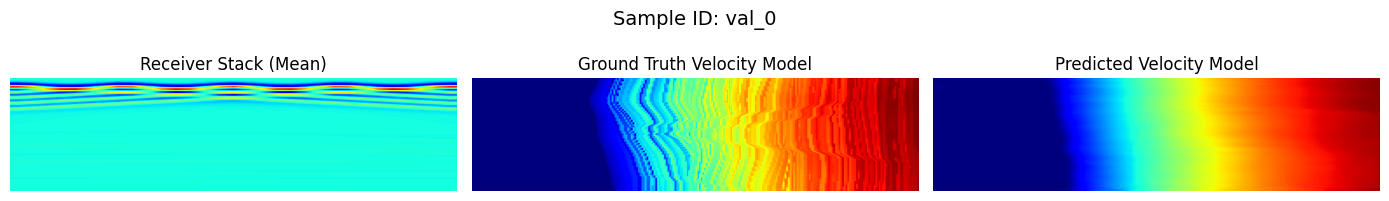

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


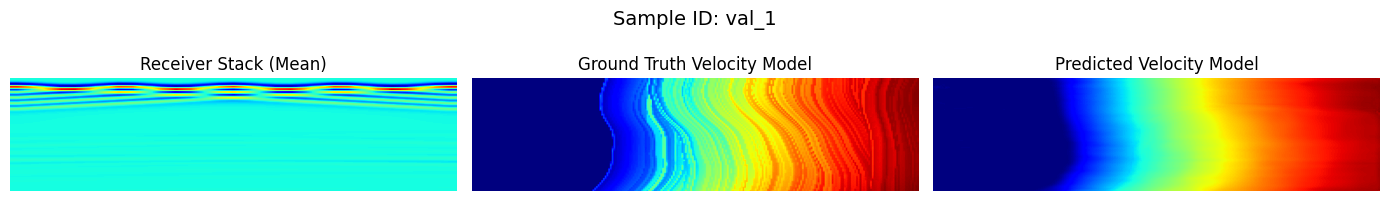

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


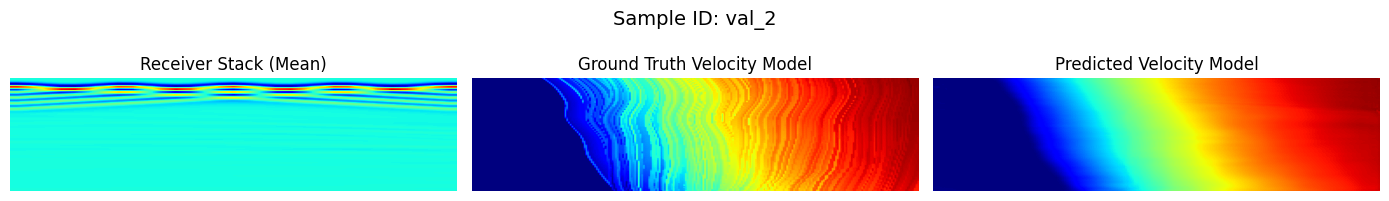

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


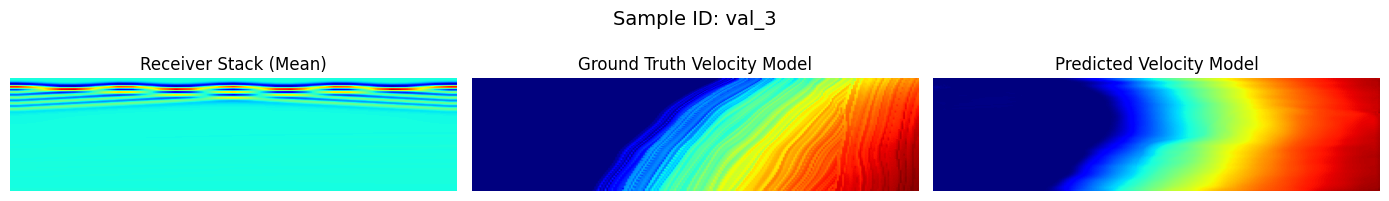

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


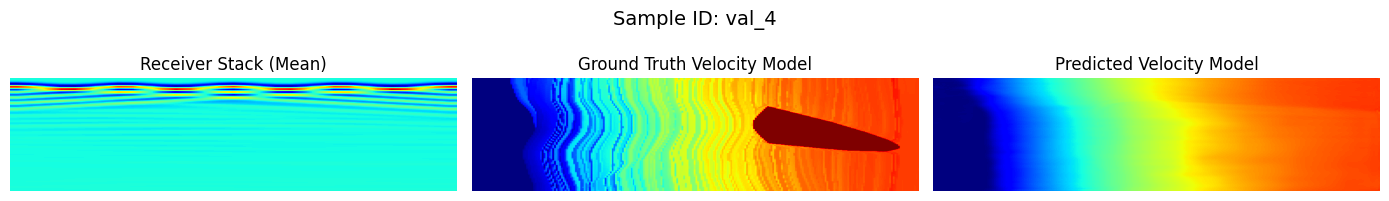

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


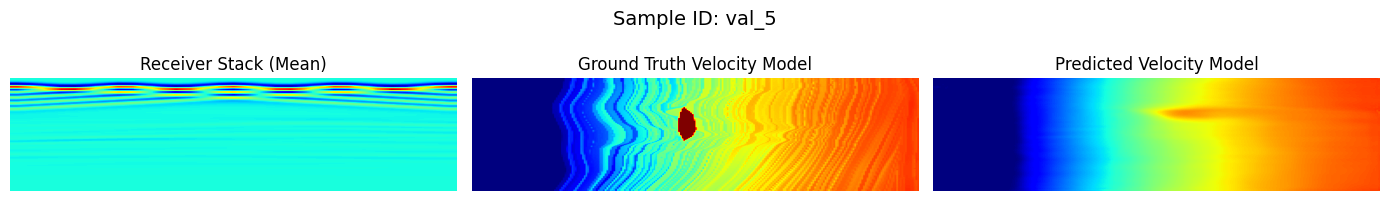

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


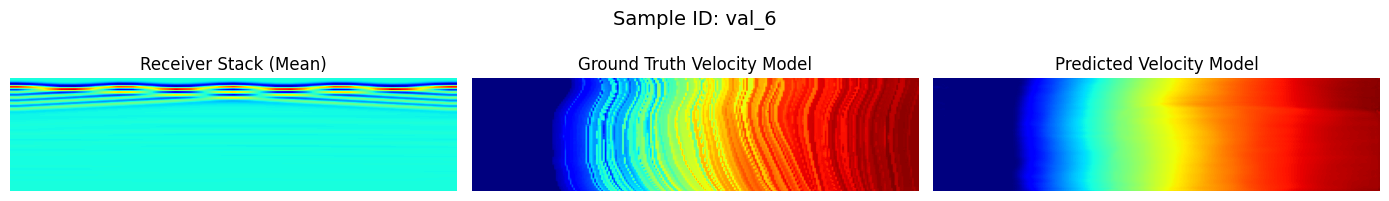

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


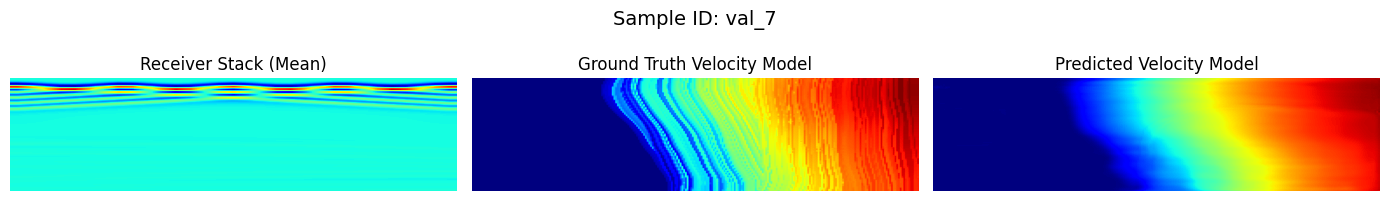

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


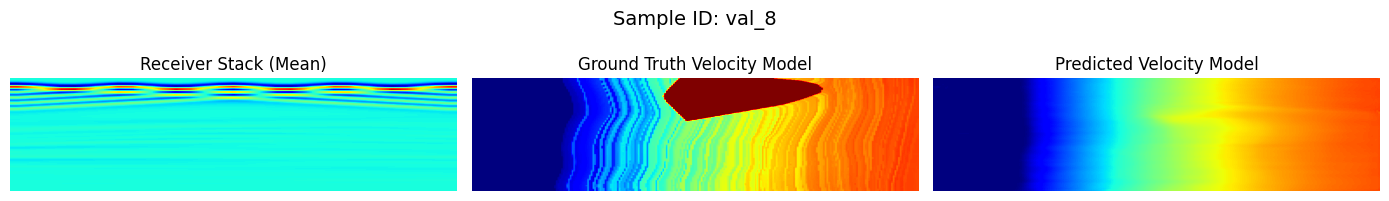

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


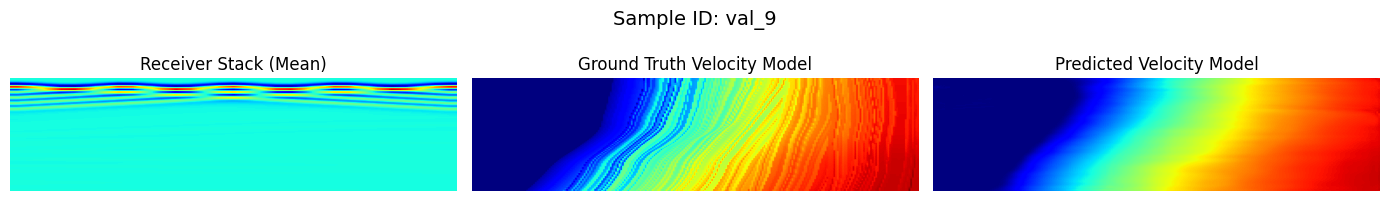

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


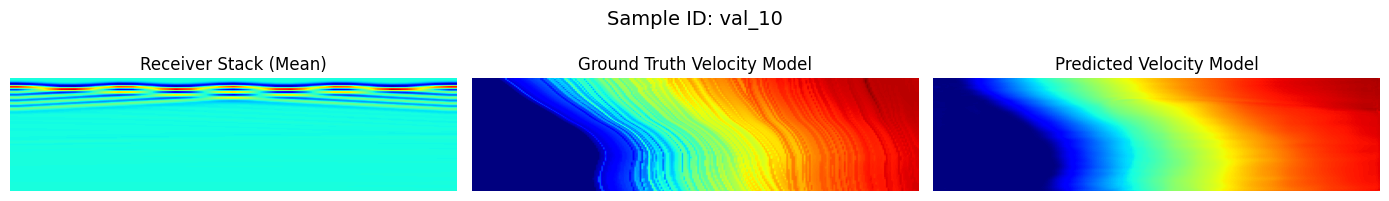

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


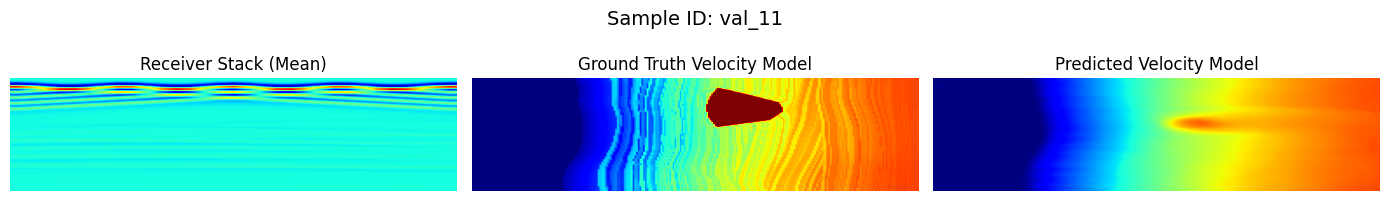

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


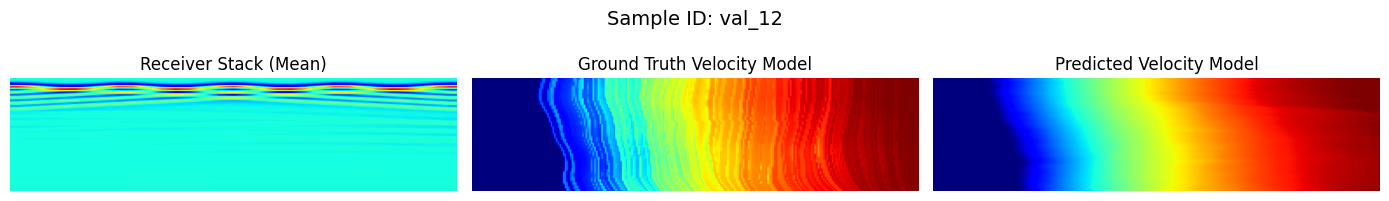

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


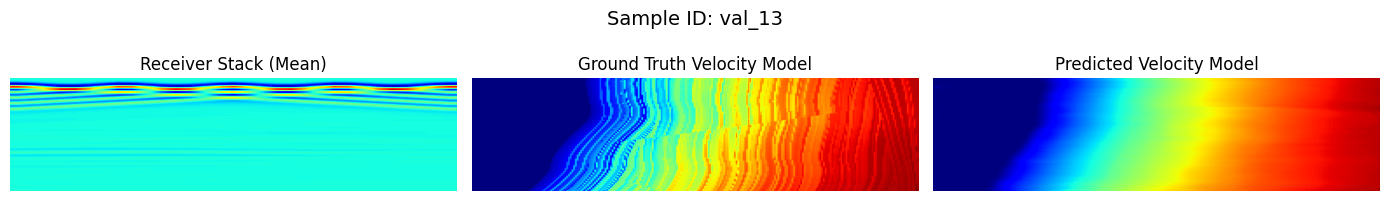

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


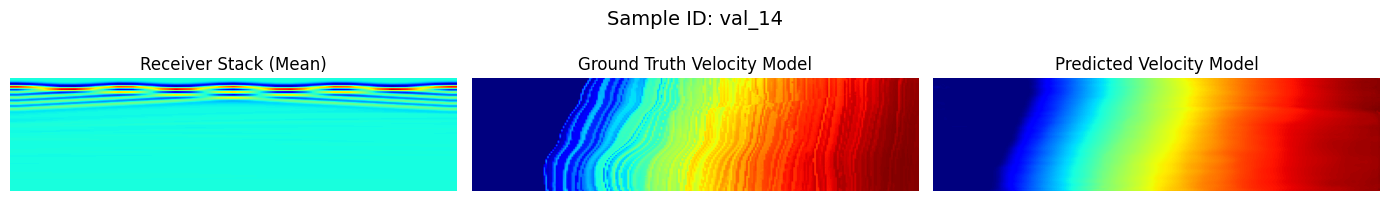

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


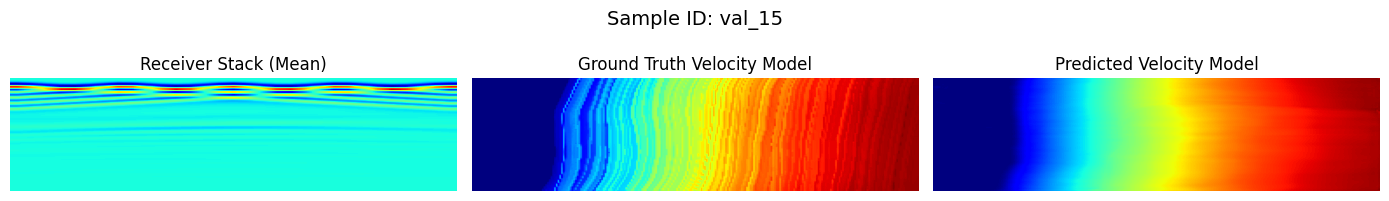

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


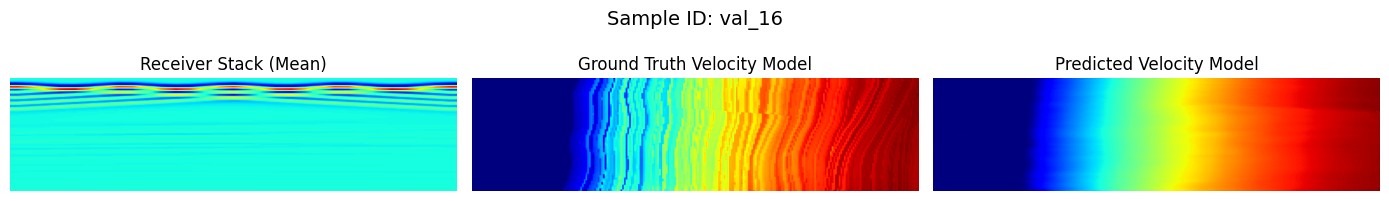

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


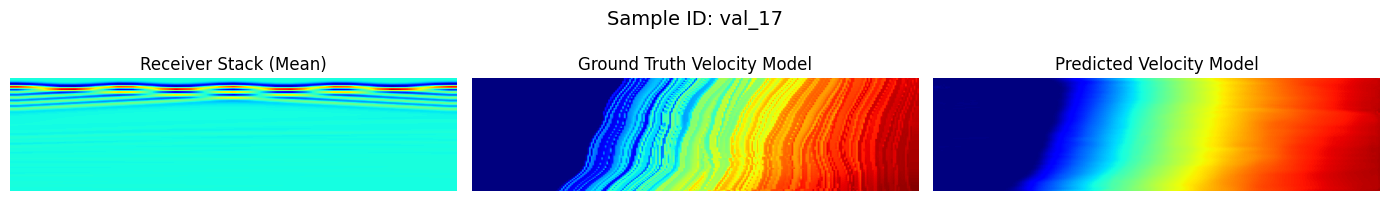

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


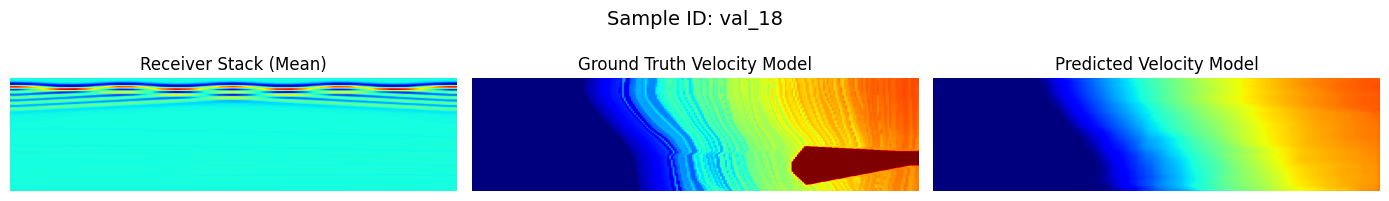

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


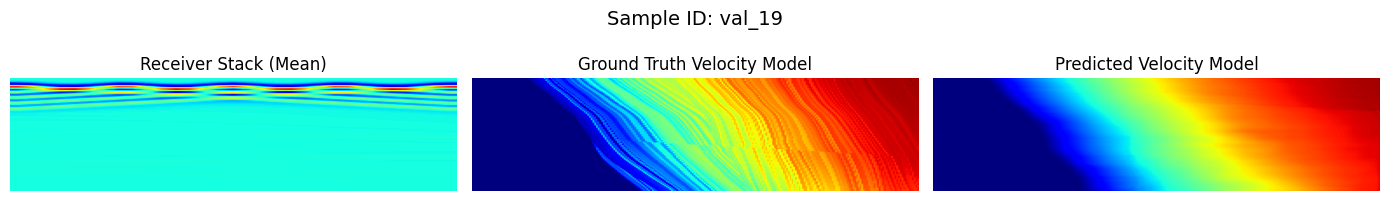

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


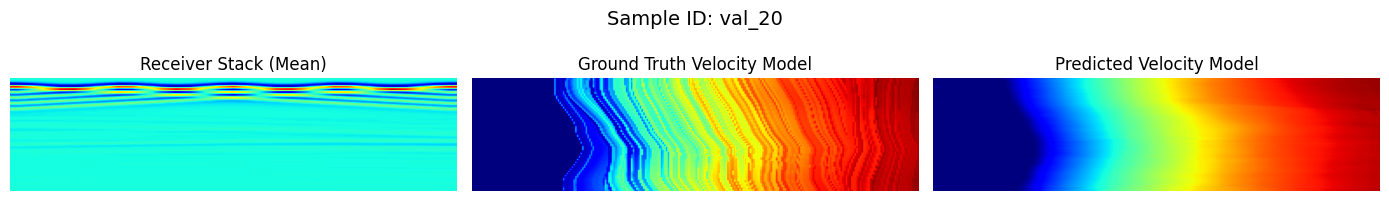

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


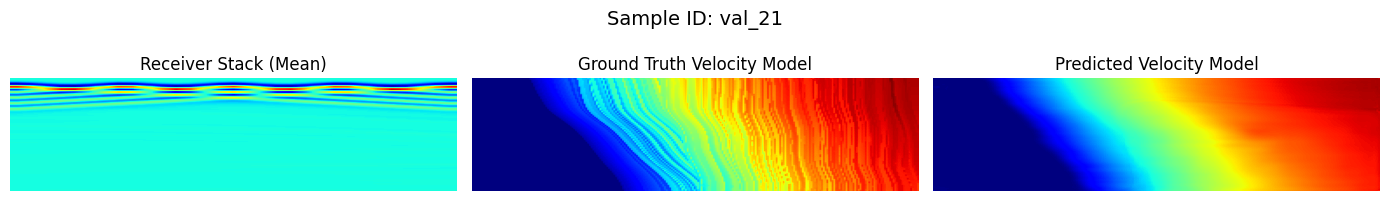

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


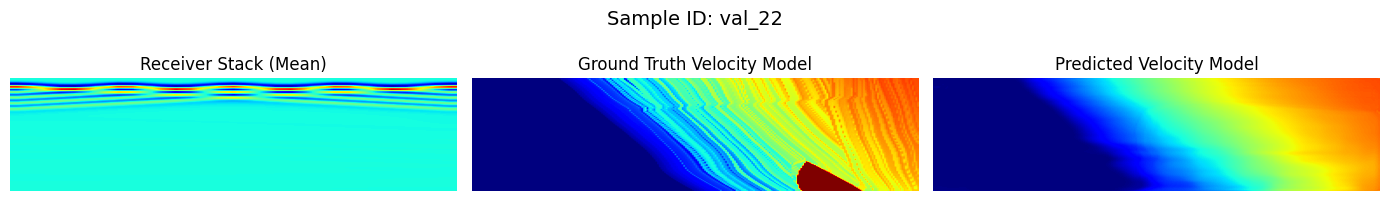

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


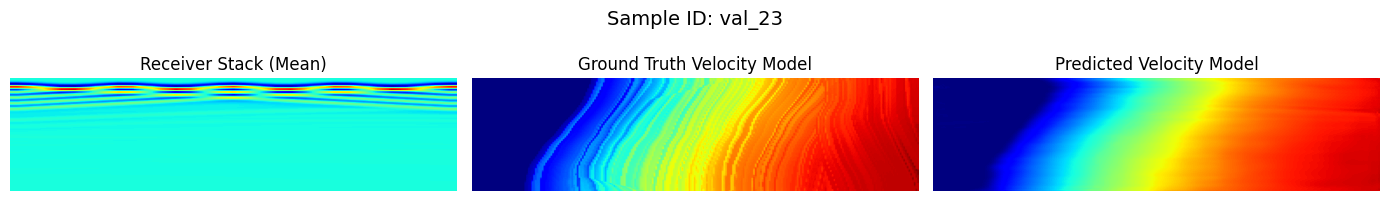

x: torch.Size([1, 5, 256, 256]), y: torch.Size([1, 256, 256]), pred: torch.Size([256, 256])


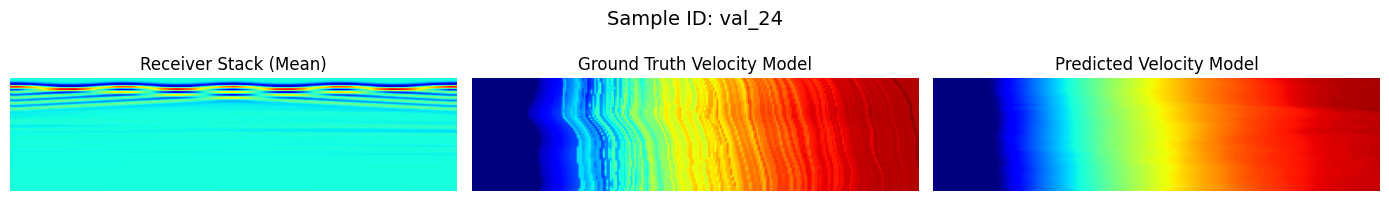

In [13]:
visualize_val_predictions(model, val_set, num_samples=25)

In [ ]:
# sample_paths = sorted(glob("/kaggle/input/train-*/**", recursive=True))
X = extract_features_for_clustering(sample_paths)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
visualize_clusters(sample_paths, kmeans.labels_, extract_features_for_clustering)
